# Analisis Bahan Pangan Indonesia

Notebook ini berisi alur analisis data dari `main.py` dalam format yang lebih mudah dicek per bagian. Setiap tahap dipisahkan menjadi cell tersendiri agar output data wrangling, EDA, visualisasi, A/B testing, data dictionary, dan insight bisa diperiksa secara bertahap.

## Ringkasan Alur

1. Load dataset.
2. Definisi masalah dan solusi utama.
3. Assessing data.
4. Cleaning data.
5. Kategori dan feature engineering `skor_kesehatan`.
6. EDA dan visualisasi.
7. A/B testing sederhana.
8. Data dictionary, data model-ready, dan business insight.

## 0. Setup

In [36]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display
from scipy.stats import ttest_ind

%matplotlib inline

pd.options.display.max_columns = None

DATA_DIR = Path('data')
NUMERIC_COLUMNS = ['kalori', 'protein', 'karbo', 'lemak', 'harga']

CATEGORY_RULES = {
    'Karbohidrat': ['beras', 'nasi', 'kentang', 'roti', 'mie', 'jagung'],
    'Protein': ['ikan', 'ayam', 'daging', 'tahu', 'tempe', 'telur', 'susu', 'udang'],
    'Sayur': [
        'brokoli', 'wortel', 'bayam', 'kangkung', 'sawi', 'mentimun',
        'kol', 'selada', 'tomat', 'cabai',
    ],
    'Buah': ['pepaya', 'melon', 'apel', 'pisang', 'jeruk', 'mangga', 'semangka'],
    'Minuman': ['teh', 'kopi', 'jus'],
}

BUSINESS_QUESTIONS = [
    'Bagaimana distribusi kategori bahan pangan dalam dataset?',
    'Bahan pangan apa saja yang memiliki protein tertinggi per 100 gram?',
    'Bahan pangan apa saja yang memiliki harga paling rendah?',
    'Bahan pangan apa saja yang memiliki kalori tertinggi?',
    'Bahan pangan apa saja yang memiliki skor_kesehatan tertinggi?',
    'Apakah rata-rata skor_kesehatan makanan murah berbeda dengan makanan mahal?',
]

DATA_DICTIONARY = {
    'nama_makanan': 'Nama bahan pangan',
    'kategori': 'Kategori makanan',
    'kalori': 'Jumlah kalori per 100g',
    'protein': 'Jumlah protein per 100g',
    'lemak': 'Jumlah lemak per 100g',
    'karbo': 'Jumlah karbohidrat per 100g',
    'harga': 'Harga makanan per kilogram',
    'skor_kesehatan': 'Skor kesehatan hasil feature engineering',
}

In [37]:
def kategori_makanan(nama):
    nama = str(nama).lower()

    for kategori, keywords in CATEGORY_RULES.items():
        if any(keyword in nama for keyword in keywords):
            return kategori

    return 'Lainnya'


def show_title(text):
    display(Markdown(f'### {text}'))

## 1. Cek File dan Load Dataset

In [38]:
display(Markdown('**Isi folder project**'))
display([path.name for path in Path('.').iterdir()])

display(Markdown('**Isi folder data**'))
display([path.name for path in DATA_DIR.iterdir()])

df1 = pd.read_csv(
    DATA_DIR / 'data_final_identik.csv',
    engine='python',
    on_bad_lines='skip',
)

df2 = pd.read_excel(DATA_DIR / 'data_set_bahan_pangan_1000.xlsx')

pd.DataFrame({
    'dataset': ['Dataset 1', 'Dataset 2'],
    'baris': [df1.shape[0], df2.shape[0]],
    'kolom': [df1.shape[1], df2.shape[1]],
})

**Isi folder project**

['ab_testing_result.csv',
 'app.py',
 'data',
 'data_dictionary.csv',
 'data_final.csv',
 'data_model_ready.csv',
 'main.ipynb',
 'main.py',
 'streamlit.err.log',
 'streamlit.log',
 '__pycache__']

**Isi folder data**

['data_final_identik.csv', 'data_set_bahan_pangan_1000.xlsx']

,dataset,baris,kolom
0,Dataset 1,6426,7
1,Dataset 2,1000,7


## 2. Problem Statement

**Masalah utama:** pengguna membutuhkan rekomendasi bahan pangan yang mempertimbangkan gizi dan harga.

**Solusi utama:** analisis dan rekomendasi makanan berbasis data menggunakan kategori, informasi gizi, harga, dan `skor_kesehatan`.

## 3. Data Awal

In [39]:
show_title('Dataset 1')
display(df1.head())

show_title('Dataset 2')
display(df2.head())

### Dataset 1

,nama_makanan,kalori,protein,lemak,karbo,harga,harga_rp;
0,margarine with yoghurt,88.0,0.058,9.8,0.073,NaN,12500;
1,sunflower seed butter,99.0,2.800,8.8,3.700,NaN,39500;
2,hazelnut oil,120.0,0.000,13.6,0.000,NaN,50500;
3,menhaden fish oil,1966.0,0.000,218.0,0.000,NaN,36000;
4,cod liver fish oil,123.0,0.000,13.6,0.000,NaN,61500;


### Dataset 2

,No,Bahan Pangan,Kalori (kkal/100g),Protein (g/100g),Karbohidrat (g/100g),Lemak (g/100g),Harga (Rp/kg)
0,1,Tahu Curah,383,18.3,38.3,7.1,Rp41.337
1,2,Pepaya Merah,92,2.0,22.9,1.3,Rp52.038
2,3,Teh Organik,20,6.7,28.0,2.2,Rp32.525
3,4,Melon Manis,85,1.8,20.9,1.2,Rp42.135
4,5,Mentimun Merah,33,2.2,7.6,0.9,Rp8.758


## 4. Assessing Data

Bagian ini mengecek struktur data, missing value, tipe data, dan jumlah duplikat. Duplikat hanya dilaporkan, tidak dihapus.

In [40]:
show_title('Info Dataset 1')
df1.info()

show_title('Info Dataset 2')
df2.info()

assessment_summary = pd.DataFrame({
    'dataset': ['Dataset 1', 'Dataset 2'],
    'baris': [df1.shape[0], df2.shape[0]],
    'kolom': [df1.shape[1], df2.shape[1]],
    'jumlah_duplikat': [df1.duplicated().sum(), df2.duplicated().sum()],
})

show_title('Ringkasan Struktur Data')
display(assessment_summary)

show_title('Missing Value Dataset 1')
display(df1.isnull().sum().to_frame('jumlah_missing'))

show_title('Missing Value Dataset 2')
display(df2.isnull().sum().to_frame('jumlah_missing'))

### Info Dataset 1

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6426 entries, 0 to 6425
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   nama_makanan  6426 non-null   object 
 1   kalori        6402 non-null   float64
 2   protein       6402 non-null   float64
 3   lemak         6402 non-null   float64
 4   karbo         6402 non-null   float64
 5   harga         0 non-null      float64
 6   harga_rp;     6426 non-null   object 
dtypes: float64(5), object(2)
memory usage: 351.6+ KB


### Info Dataset 2

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   No                    1000 non-null   int64  
 1   Bahan Pangan          1000 non-null   object 
 2   Kalori (kkal/100g)    1000 non-null   int64  
 3   Protein (g/100g)      1000 non-null   float64
 4   Karbohidrat (g/100g)  1000 non-null   float64
 5   Lemak (g/100g)        1000 non-null   float64
 6   Harga (Rp/kg)         1000 non-null   object 
dtypes: float64(3), int64(2), object(2)
memory usage: 54.8+ KB


### Ringkasan Struktur Data

,dataset,baris,kolom,jumlah_duplikat
0,Dataset 1,6426,7,0
1,Dataset 2,1000,7,0


### Missing Value Dataset 1

,jumlah_missing
nama_makanan,0
kalori,24
protein,24
lemak,24
karbo,24
harga,6426
harga_rp;,0


### Missing Value Dataset 2

,jumlah_missing
No,0
Bahan Pangan,0
Kalori (kkal/100g),0
Protein (g/100g),0
Karbohidrat (g/100g),0
Lemak (g/100g),0
Harga (Rp/kg),0


## 5. Cleaning Data

Cleaning dilakukan pada nama kolom, nama makanan, harga, dan tipe data numerik.

In [41]:
df2_clean = df2.rename(columns={
    'Bahan Pangan': 'nama_makanan',
    'Kalori (kkal/100g)': 'kalori',
    'Protein (g/100g)': 'protein',
    'Karbohidrat (g/100g)': 'karbo',
    'Lemak (g/100g)': 'lemak',
    'Harga (Rp/kg)': 'harga',
})

df2_clean['nama_makanan'] = df2_clean['nama_makanan'].astype(str).str.strip()

df2_clean['harga'] = (
    df2_clean['harga']
    .astype(str)
    .str.replace('Rp', '', regex=False)
    .str.replace('.', '', regex=False)
    .str.strip()
)

for column in NUMERIC_COLUMNS:
    df2_clean[column] = pd.to_numeric(df2_clean[column], errors='coerce')

missing_numeric = df2_clean[NUMERIC_COLUMNS].isnull().sum()

if missing_numeric.sum() > 0:
    df2_clean[NUMERIC_COLUMNS] = df2_clean[NUMERIC_COLUMNS].fillna(
        df2_clean[NUMERIC_COLUMNS].median()
    )

show_title('Missing Value Setelah Konversi Numerik')
display(missing_numeric.to_frame('jumlah_missing'))

show_title('Tipe Data Setelah Cleaning')
display(df2_clean.dtypes.to_frame('tipe_data'))

show_title('Statistik Numerik Setelah Cleaning')
display(df2_clean[NUMERIC_COLUMNS].describe())

### Missing Value Setelah Konversi Numerik

,jumlah_missing
kalori,0
protein,0
karbo,0
lemak,0
harga,0


### Tipe Data Setelah Cleaning

,tipe_data
No,int64
nama_makanan,object
kalori,int64
protein,float64
karbo,float64
lemak,float64
harga,int64


### Statistik Numerik Setelah Cleaning

,kalori,protein,karbo,lemak,harga
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,207.041000,12.362300,23.770900,9.214500,49392.719000
std,149.260376,9.907192,24.876581,10.383596,38919.312117
min,11.000000,0.000000,0.000000,0.000000,5004.000000
25%,74.000000,3.100000,4.000000,1.000000,19702.000000
50%,167.000000,8.100000,14.900000,4.700000,36557.500000
75%,345.000000,21.625000,34.000000,14.800000,68166.500000
max,600.000000,34.700000,81.900000,44.300000,178294.000000


## 6. Kategori dan Feature Engineering

Kolom `kategori` dibuat dari keyword pada `nama_makanan`. Kolom `skor_kesehatan` dibuat dengan rumus:

`skor_kesehatan = (protein * 2) + karbo - lemak`

In [42]:
df2_clean['kategori'] = df2_clean['nama_makanan'].apply(kategori_makanan)
df2_clean['skor_kesehatan'] = (
    (df2_clean['protein'] * 2)
    + df2_clean['karbo']
    - df2_clean['lemak']
)

show_title('Jumlah Data per Kategori')
display(df2_clean['kategori'].value_counts().to_frame('jumlah_data'))

show_title('Contoh Data Setelah Feature Engineering')
display(df2_clean[['nama_makanan', 'kategori', 'protein', 'karbo', 'lemak', 'skor_kesehatan']].head())

### Jumlah Data per Kategori

,jumlah_data
kategori,
Protein,334
Lainnya,262
Buah,119
Karbohidrat,105
Sayur,97
Minuman,83


### Contoh Data Setelah Feature Engineering

,nama_makanan,kategori,protein,karbo,lemak,skor_kesehatan
0,Tahu Curah,Protein,18.3,38.3,7.1,67.8
1,Pepaya Merah,Buah,2.0,22.9,1.3,25.6
2,Teh Organik,Minuman,6.7,28.0,2.2,39.2
3,Melon Manis,Buah,1.8,20.9,1.2,23.3
4,Mentimun Merah,Sayur,2.2,7.6,0.9,11.1


## 7. Data Final

In [43]:
data_final = df2_clean[[
    'nama_makanan',
    'kategori',
    'kalori',
    'protein',
    'lemak',
    'karbo',
    'harga',
    'skor_kesehatan',
]]

show_title('Preview Data Final')
display(data_final.head())

show_title('Info Data Final')
data_final.info()

show_title('Statistik Data Final')
display(data_final.describe())

### Preview Data Final

,nama_makanan,kategori,kalori,protein,lemak,karbo,harga,skor_kesehatan
0,Tahu Curah,Protein,383,18.3,7.1,38.3,41337,67.8
1,Pepaya Merah,Buah,92,2.0,1.3,22.9,52038,25.6
2,Teh Organik,Minuman,20,6.7,2.2,28.0,32525,39.2
3,Melon Manis,Buah,85,1.8,1.2,20.9,42135,23.3
4,Mentimun Merah,Sayur,33,2.2,0.9,7.6,8758,11.1


### Info Data Final

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   nama_makanan    1000 non-null   object 
 1   kategori        1000 non-null   object 
 2   kalori          1000 non-null   int64  
 3   protein         1000 non-null   float64
 4   lemak           1000 non-null   float64
 5   karbo           1000 non-null   float64
 6   harga           1000 non-null   int64  
 7   skor_kesehatan  1000 non-null   float64
dtypes: float64(4), int64(2), object(2)
memory usage: 62.6+ KB


### Statistik Data Final

,kalori,protein,lemak,karbo,harga,skor_kesehatan
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,207.041000,12.362300,9.214500,23.770900,49392.719000,39.281000
std,149.260376,9.907192,10.383596,24.876581,38919.312117,26.381397
min,11.000000,0.000000,0.000000,0.000000,5004.000000,-6.000000
25%,74.000000,3.100000,1.000000,4.000000,19702.000000,18.600000
50%,167.000000,8.100000,4.700000,14.900000,36557.500000,31.950000
75%,345.000000,21.625000,14.800000,34.000000,68166.500000,49.850000
max,600.000000,34.700000,44.300000,81.900000,178294.000000,101.300000


## 8. Business Questions dan Pembahasan

Bagian ini menyusun analisis berdasarkan pertanyaan bisnis. Setiap pertanyaan dijadikan subjudul terpisah, kemudian dijawab menggunakan exploratory data analysis, visualisasi, dan interpretasi singkat.

In [44]:
for number, question in enumerate(BUSINESS_QUESTIONS, start=1):
    print(f'{number}. {question}')

1. Bagaimana distribusi kategori bahan pangan dalam dataset?
2. Bahan pangan apa saja yang memiliki protein tertinggi per 100 gram?
3. Bahan pangan apa saja yang memiliki harga paling rendah?
4. Bahan pangan apa saja yang memiliki kalori tertinggi?
5. Bahan pangan apa saja yang memiliki skor_kesehatan tertinggi?
6. Apakah rata-rata skor_kesehatan makanan murah berbeda dengan makanan mahal?


### 8.1 Bagaimana distribusi kategori bahan pangan dalam dataset?

### Distribusi Kategori

,jumlah_data
kategori,
Protein,334
Lainnya,262
Buah,119
Karbohidrat,105
Sayur,97
Minuman,83


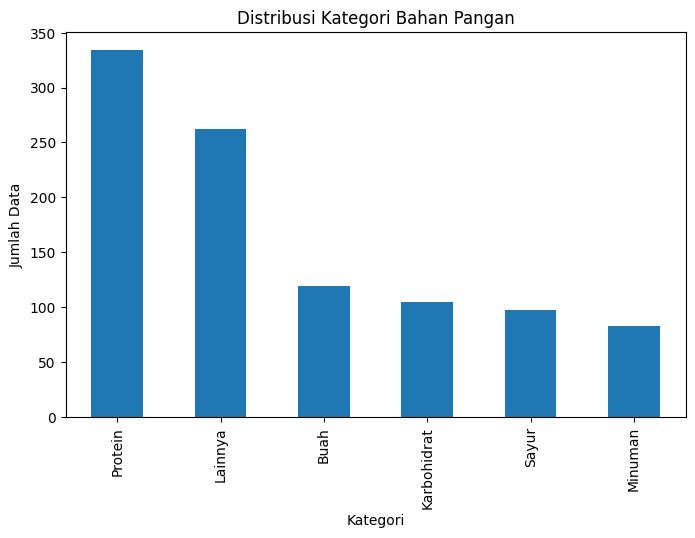

**Interpretasi:** Berdasarkan hasil distribusi kategori, kategori **Protein** menjadi kelompok bahan pangan paling dominan dengan jumlah **334 data** dari total **1000 data**. Temuan ini menunjukkan bahwa komposisi dataset lebih banyak diwakili oleh kategori tersebut, sehingga proses rekomendasi makanan perlu memperhatikan proporsi kategori agar hasil analisis tidak hanya berfokus pada satu kelompok pangan.

In [45]:
distribusi_kategori = data_final['kategori'].value_counts()
kategori_terbanyak = distribusi_kategori.idxmax()
jumlah_kategori_terbanyak = distribusi_kategori.max()
total_data = len(data_final)

show_title('Distribusi Kategori')
display(distribusi_kategori.to_frame('jumlah_data'))

ax = distribusi_kategori.plot(kind='bar', figsize=(8, 5))
ax.set_title('Distribusi Kategori Bahan Pangan')
ax.set_xlabel('Kategori')
ax.set_ylabel('Jumlah Data')
plt.show()

display(Markdown(
    f'**Interpretasi:** Berdasarkan hasil distribusi kategori, kategori '
    f'**{kategori_terbanyak}** menjadi kelompok bahan pangan paling dominan '
    f'dengan jumlah **{jumlah_kategori_terbanyak} data** dari total **{total_data} data**. '
    f'Temuan ini menunjukkan bahwa komposisi dataset lebih banyak diwakili oleh '
    f'kategori tersebut, sehingga proses rekomendasi makanan perlu memperhatikan '
    f'proporsi kategori agar hasil analisis tidak hanya berfokus pada satu kelompok pangan.'
))

### 8.2 Bahan pangan apa saja yang memiliki protein tertinggi per 100 gram?

### Top 10 Protein Tertinggi

,nama_makanan,kategori,protein,harga
210,Mete Segar,Lainnya,34.7,22173
905,Kacang Tanah Pedas,Lainnya,34.6,67745
603,Mete Beku,Lainnya,34.6,60999
839,Kacang Tanah Import,Lainnya,34.2,41733
129,Almond Lokal,Lainnya,34.1,85615
931,Kedelai Hijau,Lainnya,34.0,81305
506,Kacang Tanah Rendah Lemak,Lainnya,33.9,61552
224,Almond Asin,Lainnya,33.8,75224
293,Kacang Hijau Tinggi Protein,Lainnya,33.2,58417
258,Kacang Tanah Hijau,Lainnya,33.2,69901


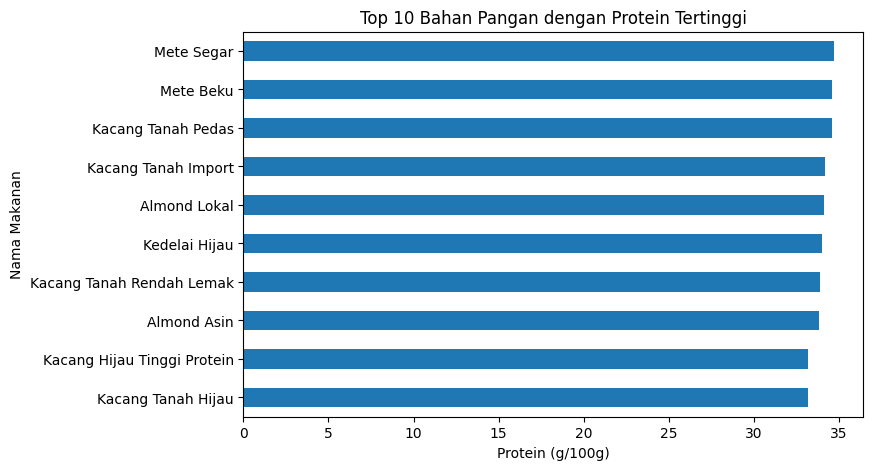

**Interpretasi:** Hasil analisis menunjukkan bahwa **Mete Segar** merupakan bahan pangan dengan kandungan protein tertinggi, yaitu **34.7 g/100g**. Hal ini menunjukkan bahwa bahan pangan tersebut dapat diprioritaskan dalam rekomendasi menu apabila tujuan pengguna adalah meningkatkan asupan protein harian.

In [46]:
top_protein = data_final.sort_values(by='protein', ascending=False).head(10)
protein_tertinggi = top_protein.iloc[0]

show_title('Top 10 Protein Tertinggi')
display(top_protein[['nama_makanan', 'kategori', 'protein', 'harga']])

ax = top_protein.sort_values('protein').plot(
    kind='barh',
    x='nama_makanan',
    y='protein',
    figsize=(8, 5),
    legend=False,
)
ax.set_title('Top 10 Bahan Pangan dengan Protein Tertinggi')
ax.set_xlabel('Protein (g/100g)')
ax.set_ylabel('Nama Makanan')
plt.show()

display(Markdown(
    f'**Interpretasi:** Hasil analisis menunjukkan bahwa **{protein_tertinggi["nama_makanan"]}** '
    f'merupakan bahan pangan dengan kandungan protein tertinggi, yaitu '
    f'**{protein_tertinggi["protein"]} g/100g**. Hal ini menunjukkan bahwa bahan pangan '
    f'tersebut dapat diprioritaskan dalam rekomendasi menu apabila tujuan pengguna adalah '
    f'meningkatkan asupan protein harian.'
))

### 8.3 Bahan pangan apa saja yang memiliki harga paling rendah?

### Top 10 Harga Terendah

,nama_makanan,kategori,harga,protein,kalori
49,Kubis Import,Lainnya,5004,3.4,56
274,Mentimun Hitam,Sayur,5221,2.8,37
242,Tomat Hitam,Sayur,5560,3.4,19
678,Kangkung Pedas,Sayur,5659,1.8,49
20,Kangkung Lokal,Sayur,5771,1.1,32
425,Wortel Putih,Sayur,5971,4.8,57
872,Tomat Pedas,Sayur,6035,2.5,45
356,Jus Organik,Minuman,6056,1.9,91
427,Kubis Segar,Lainnya,6179,3.5,16
211,Mentimun Tinggi Protein,Sayur,6324,3.0,32


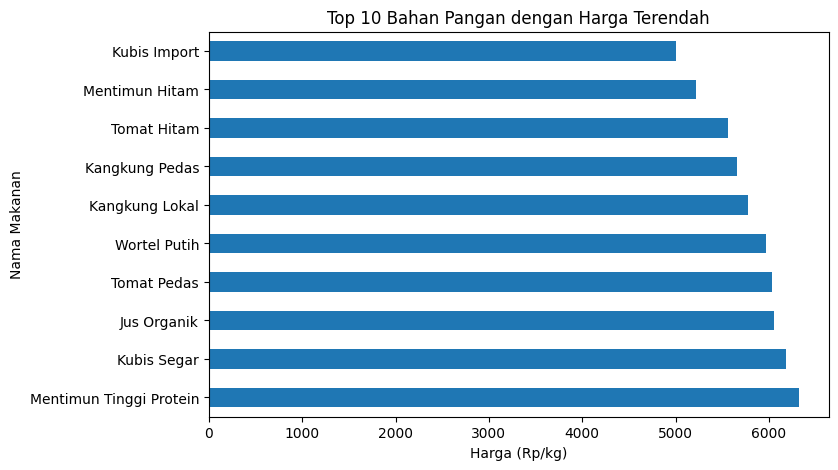

**Interpretasi:** Berdasarkan analisis harga, **Kubis Import** menjadi bahan pangan dengan harga terendah, yaitu **Rp 5,004/kg**. Temuan ini relevan untuk kebutuhan rekomendasi menu hemat, karena bahan pangan dengan harga relatif rendah dapat digunakan sebagai kandidat awal dalam penyusunan menu yang ramah anggaran.

In [47]:
top_murah = data_final.sort_values(by='harga', ascending=True).head(10)
makanan_termurah = top_murah.iloc[0]

show_title('Top 10 Harga Terendah')
display(top_murah[['nama_makanan', 'kategori', 'harga', 'protein', 'kalori']])

ax = top_murah.sort_values('harga', ascending=False).plot(
    kind='barh',
    x='nama_makanan',
    y='harga',
    figsize=(8, 5),
    legend=False,
)
ax.set_title('Top 10 Bahan Pangan dengan Harga Terendah')
ax.set_xlabel('Harga (Rp/kg)')
ax.set_ylabel('Nama Makanan')
plt.show()

display(Markdown(
    f'**Interpretasi:** Berdasarkan analisis harga, **{makanan_termurah["nama_makanan"]}** '
    f'menjadi bahan pangan dengan harga terendah, yaitu **Rp {makanan_termurah["harga"]:,.0f}/kg**. '
    f'Temuan ini relevan untuk kebutuhan rekomendasi menu hemat, karena bahan pangan dengan harga '
    f'relatif rendah dapat digunakan sebagai kandidat awal dalam penyusunan menu yang ramah anggaran.'
))

### 8.4 Bahan pangan apa saja yang memiliki kalori tertinggi?

### Top 10 Kalori Tertinggi

,nama_makanan,kategori,kalori,harga
805,Kedelai Tinggi Protein,Lainnya,600,83936
960,Almond Premium,Lainnya,598,45759
609,Kacang Tanah Premium,Lainnya,597,42120
155,Kedelai Merah,Lainnya,596,21605
212,Kacang Hijau Rendah Lemak,Lainnya,594,87431
734,Kacang Hijau Merah,Lainnya,593,22281
184,Almond Manis,Lainnya,590,62986
329,Kacang Hijau Pilihan,Lainnya,589,32306
793,Kedelai Manis,Lainnya,587,61946
756,Kacang Tanah Manis,Lainnya,584,35784


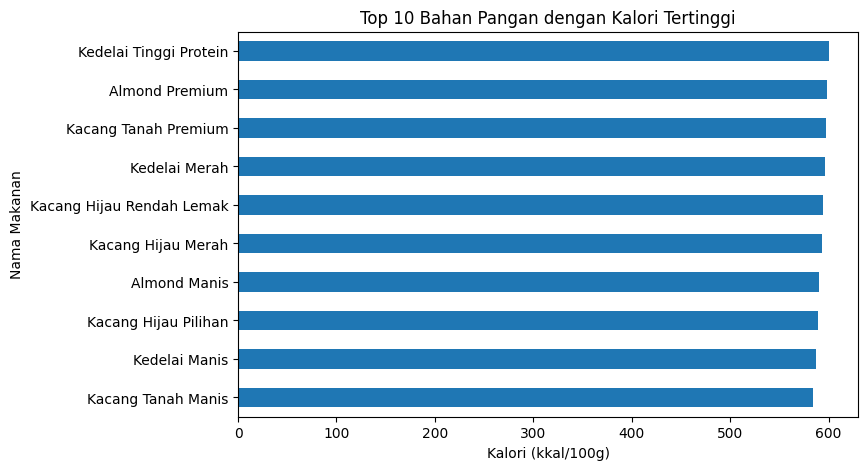

**Interpretasi:** Analisis menunjukkan bahwa **Kedelai Tinggi Protein** memiliki nilai kalori tertinggi, yaitu **600 kkal/100g**. Bahan pangan dengan kalori tinggi dapat dipertimbangkan sebagai sumber energi utama, namun penggunaannya tetap perlu diseimbangkan dengan kandungan gizi lain seperti protein, lemak, dan karbohidrat.

In [48]:
top_kalori = data_final.sort_values(by='kalori', ascending=False).head(10)
kalori_tertinggi = top_kalori.iloc[0]

show_title('Top 10 Kalori Tertinggi')
display(top_kalori[['nama_makanan', 'kategori', 'kalori', 'harga']])

ax = top_kalori.sort_values('kalori').plot(
    kind='barh',
    x='nama_makanan',
    y='kalori',
    figsize=(8, 5),
    legend=False,
)
ax.set_title('Top 10 Bahan Pangan dengan Kalori Tertinggi')
ax.set_xlabel('Kalori (kkal/100g)')
ax.set_ylabel('Nama Makanan')
plt.show()

display(Markdown(
    f'**Interpretasi:** Analisis menunjukkan bahwa **{kalori_tertinggi["nama_makanan"]}** '
    f'memiliki nilai kalori tertinggi, yaitu **{kalori_tertinggi["kalori"]} kkal/100g**. '
    f'Bahan pangan dengan kalori tinggi dapat dipertimbangkan sebagai sumber energi utama, '
    f'namun penggunaannya tetap perlu diseimbangkan dengan kandungan gizi lain seperti protein, '
    f'lemak, dan karbohidrat.'
))

### 8.5 Bahan pangan apa saja yang memiliki skor_kesehatan tertinggi?

### Top 10 Skor Kesehatan Tertinggi

,nama_makanan,kategori,protein,karbo,lemak,skor_kesehatan
465,Almond Putih,Lainnya,32.0,49.4,12.1,101.3
869,Almond Pilihan,Lainnya,33.2,47.0,13.8,99.6
577,Ketan Segar,Lainnya,8.9,80.9,0.2,98.5
905,Kacang Tanah Pedas,Lainnya,34.6,44.1,16.1,97.2
806,Ketan Pedas,Lainnya,8.3,80.7,0.2,97.1
985,Ketan Putih,Lainnya,9.0,79.2,0.3,96.9
677,Nasi Asin,Karbohidrat,8.9,79.2,0.5,96.5
102,Nasi Pilihan,Karbohidrat,8.3,80.5,0.6,96.5
765,Ketan Pedas,Lainnya,8.5,80.6,1.2,96.4
391,Ketan Rendah Lemak,Lainnya,8.6,80.3,1.3,96.2


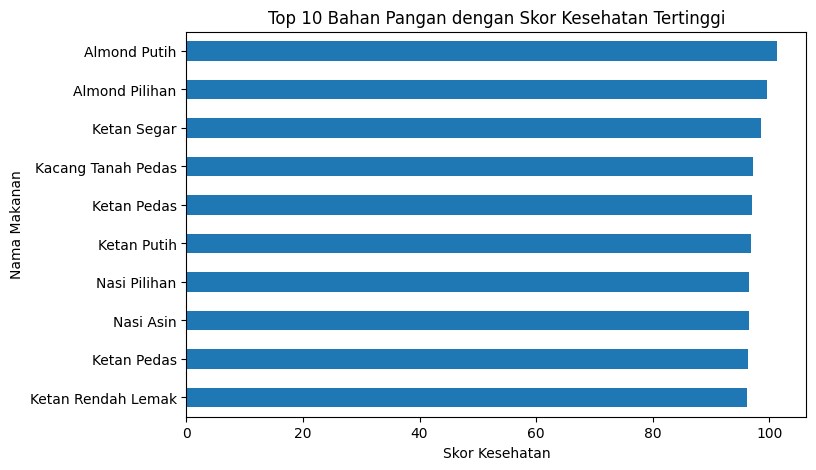

**Interpretasi:** Berdasarkan fitur `skor_kesehatan`, **Almond Putih** memiliki skor tertinggi sebesar **101.30**. Nilai ini diperoleh dari kombinasi protein, karbohidrat, dan lemak, sehingga bahan pangan dengan skor tinggi dapat dijadikan kandidat rekomendasi awal untuk menu yang lebih seimbang secara komposisi gizi.

In [49]:
top_sehat = data_final.sort_values(by='skor_kesehatan', ascending=False).head(10)
skor_tertinggi = top_sehat.iloc[0]

show_title('Top 10 Skor Kesehatan Tertinggi')
display(top_sehat[['nama_makanan', 'kategori', 'protein', 'karbo', 'lemak', 'skor_kesehatan']])

ax = top_sehat.sort_values('skor_kesehatan').plot(
    kind='barh',
    x='nama_makanan',
    y='skor_kesehatan',
    figsize=(8, 5),
    legend=False,
)
ax.set_title('Top 10 Bahan Pangan dengan Skor Kesehatan Tertinggi')
ax.set_xlabel('Skor Kesehatan')
ax.set_ylabel('Nama Makanan')
plt.show()

display(Markdown(
    f'**Interpretasi:** Berdasarkan fitur `skor_kesehatan`, **{skor_tertinggi["nama_makanan"]}** '
    f'memiliki skor tertinggi sebesar **{skor_tertinggi["skor_kesehatan"]:.2f}**. '
    f'Nilai ini diperoleh dari kombinasi protein, karbohidrat, dan lemak, sehingga bahan pangan '
    f'dengan skor tinggi dapat dijadikan kandidat rekomendasi awal untuk menu yang lebih seimbang '
    f'secara komposisi gizi.'
))

### 8.6 Apakah rata-rata skor_kesehatan makanan murah berbeda dengan makanan mahal?

### Hasil A/B Testing

**H0:** rata-rata skor_kesehatan makanan murah dan mahal sama.

**H1:** rata-rata skor_kesehatan makanan murah dan mahal berbeda.

,group,kriteria,jumlah_data,rata_rata_skor_kesehatan,t_statistic,p_value,kesimpulan
0,Group A - Murah,harga <= median harga,500,40.38,1.3231,0.1862,tidak terdapat perbedaan rata-rata skor_keseha...
1,Group B - Mahal,harga > median harga,500,38.18,1.3231,0.1862,tidak terdapat perbedaan rata-rata skor_keseha...


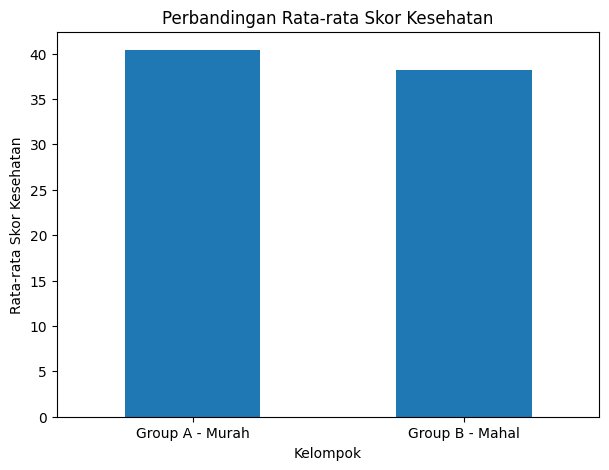

**Interpretasi:** Hasil A/B testing menggunakan Welch t-test menunjukkan nilai **p-value = 0.1862**. Dengan tingkat signifikansi 5%, hasil tersebut menunjukkan bahwa **tidak terdapat perbedaan rata-rata skor_kesehatan yang signifikan antara makanan murah dan mahal**. Artinya, berdasarkan data yang dianalisis, perbedaan harga murah dan mahal belum tentu diikuti oleh perbedaan kualitas skor kesehatan yang bermakna secara statistik.

In [50]:
median_harga = data_final['harga'].median()

group_a = data_final[data_final['harga'] <= median_harga]
group_b = data_final[data_final['harga'] > median_harga]

skor_group_a = group_a['skor_kesehatan'].dropna()
skor_group_b = group_b['skor_kesehatan'].dropna()

t_stat, p_value = ttest_ind(skor_group_a, skor_group_b, equal_var=False)

if p_value < 0.05:
    ab_test_kesimpulan = (
        'terdapat perbedaan rata-rata skor_kesehatan yang signifikan '
        'antara makanan murah dan mahal'
    )
else:
    ab_test_kesimpulan = (
        'tidak terdapat perbedaan rata-rata skor_kesehatan yang signifikan '
        'antara makanan murah dan mahal'
    )

ab_test_result = pd.DataFrame([
    {
        'group': 'Group A - Murah',
        'kriteria': 'harga <= median harga',
        'jumlah_data': len(group_a),
        'rata_rata_skor_kesehatan': round(skor_group_a.mean(), 2),
        't_statistic': round(t_stat, 4),
        'p_value': round(p_value, 4),
        'kesimpulan': ab_test_kesimpulan,
    },
    {
        'group': 'Group B - Mahal',
        'kriteria': 'harga > median harga',
        'jumlah_data': len(group_b),
        'rata_rata_skor_kesehatan': round(skor_group_b.mean(), 2),
        't_statistic': round(t_stat, 4),
        'p_value': round(p_value, 4),
        'kesimpulan': ab_test_kesimpulan,
    },
])

show_title('Hasil A/B Testing')
display(Markdown('**H0:** rata-rata skor_kesehatan makanan murah dan mahal sama.'))
display(Markdown('**H1:** rata-rata skor_kesehatan makanan murah dan mahal berbeda.'))
display(ab_test_result)

ax = ab_test_result.plot(
    kind='bar',
    x='group',
    y='rata_rata_skor_kesehatan',
    figsize=(7, 5),
    legend=False,
)
ax.set_title('Perbandingan Rata-rata Skor Kesehatan')
ax.set_xlabel('Kelompok')
ax.set_ylabel('Rata-rata Skor Kesehatan')
plt.xticks(rotation=0)
plt.show()

display(Markdown(
    f'**Interpretasi:** Hasil A/B testing menggunakan Welch t-test menunjukkan nilai '
    f'**p-value = {p_value:.4f}**. Dengan tingkat signifikansi 5%, hasil tersebut menunjukkan bahwa '
    f'**{ab_test_kesimpulan}**. Artinya, berdasarkan data yang dianalisis, perbedaan harga murah '
    f'dan mahal belum tentu diikuti oleh perbedaan kualitas skor kesehatan yang bermakna secara statistik.'
))

## 9. Ringkasan EDA per Kategori

Bagian ini merangkum hasil analisis kategori sebagai pelengkap pembahasan pertanyaan bisnis.

### Ringkasan per Kategori

,jumlah_data,rata_rata_harga,rata_rata_protein,rata_rata_kalori,rata_rata_skor_kesehatan
kategori,,,,,
Protein,334,82016.06,18.92,180.94,34.11
Lainnya,262,42096.95,16.45,355.96,55.01
Buah,119,33798.13,1.52,73.90,20.88
Karbohidrat,105,28077.76,8.53,330.48,76.42
Sayur,97,20758.76,3.08,36.21,13.24
Minuman,83,23930.25,4.31,76.39,20.27


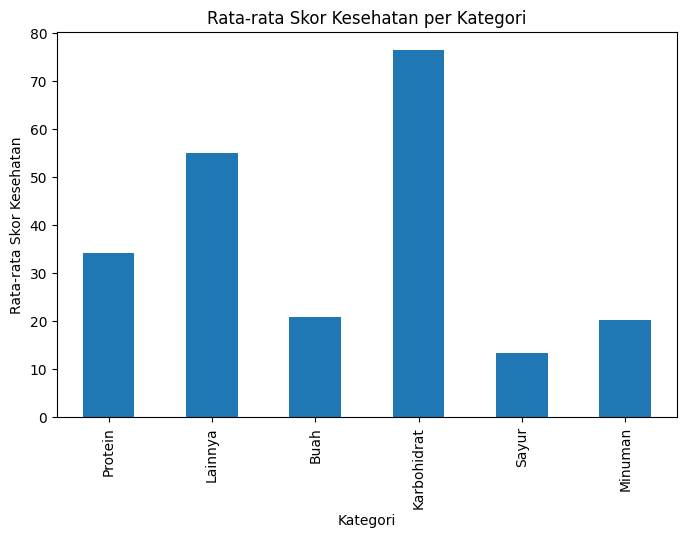

In [51]:
eda_kategori = data_final.groupby('kategori').agg(
    jumlah_data=('nama_makanan', 'count'),
    rata_rata_harga=('harga', 'mean'),
    rata_rata_protein=('protein', 'mean'),
    rata_rata_kalori=('kalori', 'mean'),
    rata_rata_skor_kesehatan=('skor_kesehatan', 'mean'),
).round(2).sort_values(by='jumlah_data', ascending=False)

show_title('Ringkasan per Kategori')
display(eda_kategori)

ax = eda_kategori['rata_rata_skor_kesehatan'].plot(kind='bar', figsize=(8, 5))
ax.set_title('Rata-rata Skor Kesehatan per Kategori')
ax.set_xlabel('Kategori')
ax.set_ylabel('Rata-rata Skor Kesehatan')
plt.show()

## 10. Data Dictionary dan Data Model-Ready

In [52]:
data_dictionary_df = pd.DataFrame(
    DATA_DICTIONARY.items(),
    columns=['kolom', 'deskripsi'],
)

data_model_ready = data_final[[
    'kategori',
    'kalori',
    'protein',
    'lemak',
    'karbo',
    'harga',
    'skor_kesehatan',
]]

show_title('Data Dictionary')
display(data_dictionary_df)

show_title('Data Model-Ready')
display(data_model_ready.head())

### Data Dictionary

,kolom,deskripsi
0,nama_makanan,Nama bahan pangan
1,kategori,Kategori makanan
2,kalori,Jumlah kalori per 100g
3,protein,Jumlah protein per 100g
4,lemak,Jumlah lemak per 100g
5,karbo,Jumlah karbohidrat per 100g
6,harga,Harga makanan per kilogram
7,skor_kesehatan,Skor kesehatan hasil feature engineering


### Data Model-Ready

,kategori,kalori,protein,lemak,karbo,harga,skor_kesehatan
0,Protein,383,18.3,7.1,38.3,41337,67.8
1,Buah,92,2.0,1.3,22.9,52038,25.6
2,Minuman,20,6.7,2.2,28.0,32525,39.2
3,Buah,85,1.8,1.2,20.9,42135,23.3
4,Sayur,33,2.2,0.9,7.6,8758,11.1


## 11. Simpan Output Analisis

Cell ini menyimpan output utama agar bisa dipakai oleh dashboard Streamlit atau proses berikutnya.

In [56]:
data_final.to_csv('output/data_final.csv', index=False)
data_dictionary_df.to_csv('output/data_dictionary.csv', index=False)
data_model_ready.to_csv('output/data_model_ready.csv', index=False)
ab_test_result.to_csv('output/ab_testing_result.csv', index=False)

display(Markdown('Output berhasil disimpan:'))
display([
    'output/data_final.csv',
    'output/data_dictionary.csv',
    'output/data_model_ready.csv',
    'output/ab_testing_result.csv',
])

Output berhasil disimpan:

['output/data_final.csv',
 'output/data_dictionary.csv',
 'output/data_model_ready.csv',
 'output/ab_testing_result.csv']